## Question 1

In [1]:
# Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")



'''
To Do:
1. Sistemare il plotting dei grafici perche stampino le serie corrette.
2. procedere con le domande 2-3-4
'''

'\nTo Do:\n1. Sistemare il plotting dei grafici perche stampino le serie corrette.\n2. procedere con le domande 2-3-4\n'

### Data Description

| Category          | Variable | 
|--------------------|-----------|
| **Equity Index**   | S&P 500 | 
| **Government Yield** | US Treasury (10-year constant maturity) |
| **Corporate Yield** | ICE BofA US Corporate Index | 
| **Commodity**       | Crude Oil WTI (CL1 Quote) |
| **Forex Rate**      | EUR/USD |


In [2]:
# data import
equity_idx = pd.read_excel('../data/SPX Index.xlsx', header=5, usecols=[4, 5], index_col=0, names=['date', 'SPX'])
commodity = pd.read_excel('../data/GAS.xlsx', header=0, index_col=0, names=['date', 'Gas'])
fx_rate = pd.read_excel('../data/GBPUSD.xlsx', header=5, usecols=[4, 5], index_col=0, names=['date', 'GBPUSD'])
gvt_yield = pd.read_excel('../data/DGS10.xlsx', sheet_name='Daily', header=0, index_col=0, names=['date', '10yr Tr. Yield'])
corporate_yield = pd.read_excel('../data/BAMLC0A0CMEY.xlsx', sheet_name='Daily, Close', header=0, index_col=0, names=['date', 'US Yields'])
uk_gilt = pd.read_excel('../data/UKGilt.xlsx', header=0, index_col=0, names=['date', 'UKGilt'])


<span style="font-family:'Times New Roman', Times, serif; font-size:16px;">

## Data Aggregation
In the following block of code we are going to aggregate the data into 4 DataFrames:

1. df_level : containing a raw aggregation of the data
2. df_log : containing the log-levels (for Fixed Income Sec. we performed a conversion of the Yield | compound → continuous)
3. df_log_diff : containing log-differences
4. df : comprehensive DataFrame built via an inner join of the former three.

In [3]:
# Raw Levels aggregation 
df_level = pd.concat([equity_idx, gvt_yield, corporate_yield, commodity, fx_rate], join='inner', axis=1)
df_level = df_level.dropna(axis=0)
df_level['spread 10yr_Tr-Corp'] = df_level['US Yields'] - df_level['10yr Tr. Yield']

# Log-Levels
log_eq_idx = np.log(equity_idx)
log_commodity = np.log(commodity)
log_fx = np.log(fx_rate)
log_gvt = np.log(1 + (gvt_yield / 100))
log_corp = np.log(1 + (corporate_yield / 100))

# Log Dataframe
df_log = pd.concat([log_eq_idx, log_commodity, log_fx, log_gvt, log_corp], join='inner', axis=1).dropna(axis=0)
df_log.columns = [f'log {equity_idx.columns[0]}',
                f'log {commodity.columns[0]}',
                f'log {fx_rate.columns[0]}',
                f'log {gvt_yield.columns[0]}',
                f'log {corporate_yield.columns[0]}']
df_log[f'log {df_level.columns.to_list()[-1]}'] = df_log[f'log {gvt_yield.columns[0]}'] - df_log[f'log {corporate_yield.columns[0]}']

# Log-Differences Dataframe
df_log_diff = df_log.diff().dropna(axis=0)
df_log_diff.columns = [f'logDiff {equity_idx.columns[0]}',
                f'logDiff {commodity.columns[0]}',
                f'logDiff {fx_rate.columns[0]}',
                f'logDiff {gvt_yield.columns[0]}',
                f'logDiff {corporate_yield.columns[0]}',
                f'logDiff {df_level.columns.tolist()[-1]}']
# Comprehensive Dataframe
df = pd.concat([df_level, df_log, df_log_diff], join='inner', axis=1).dropna(axis=0)

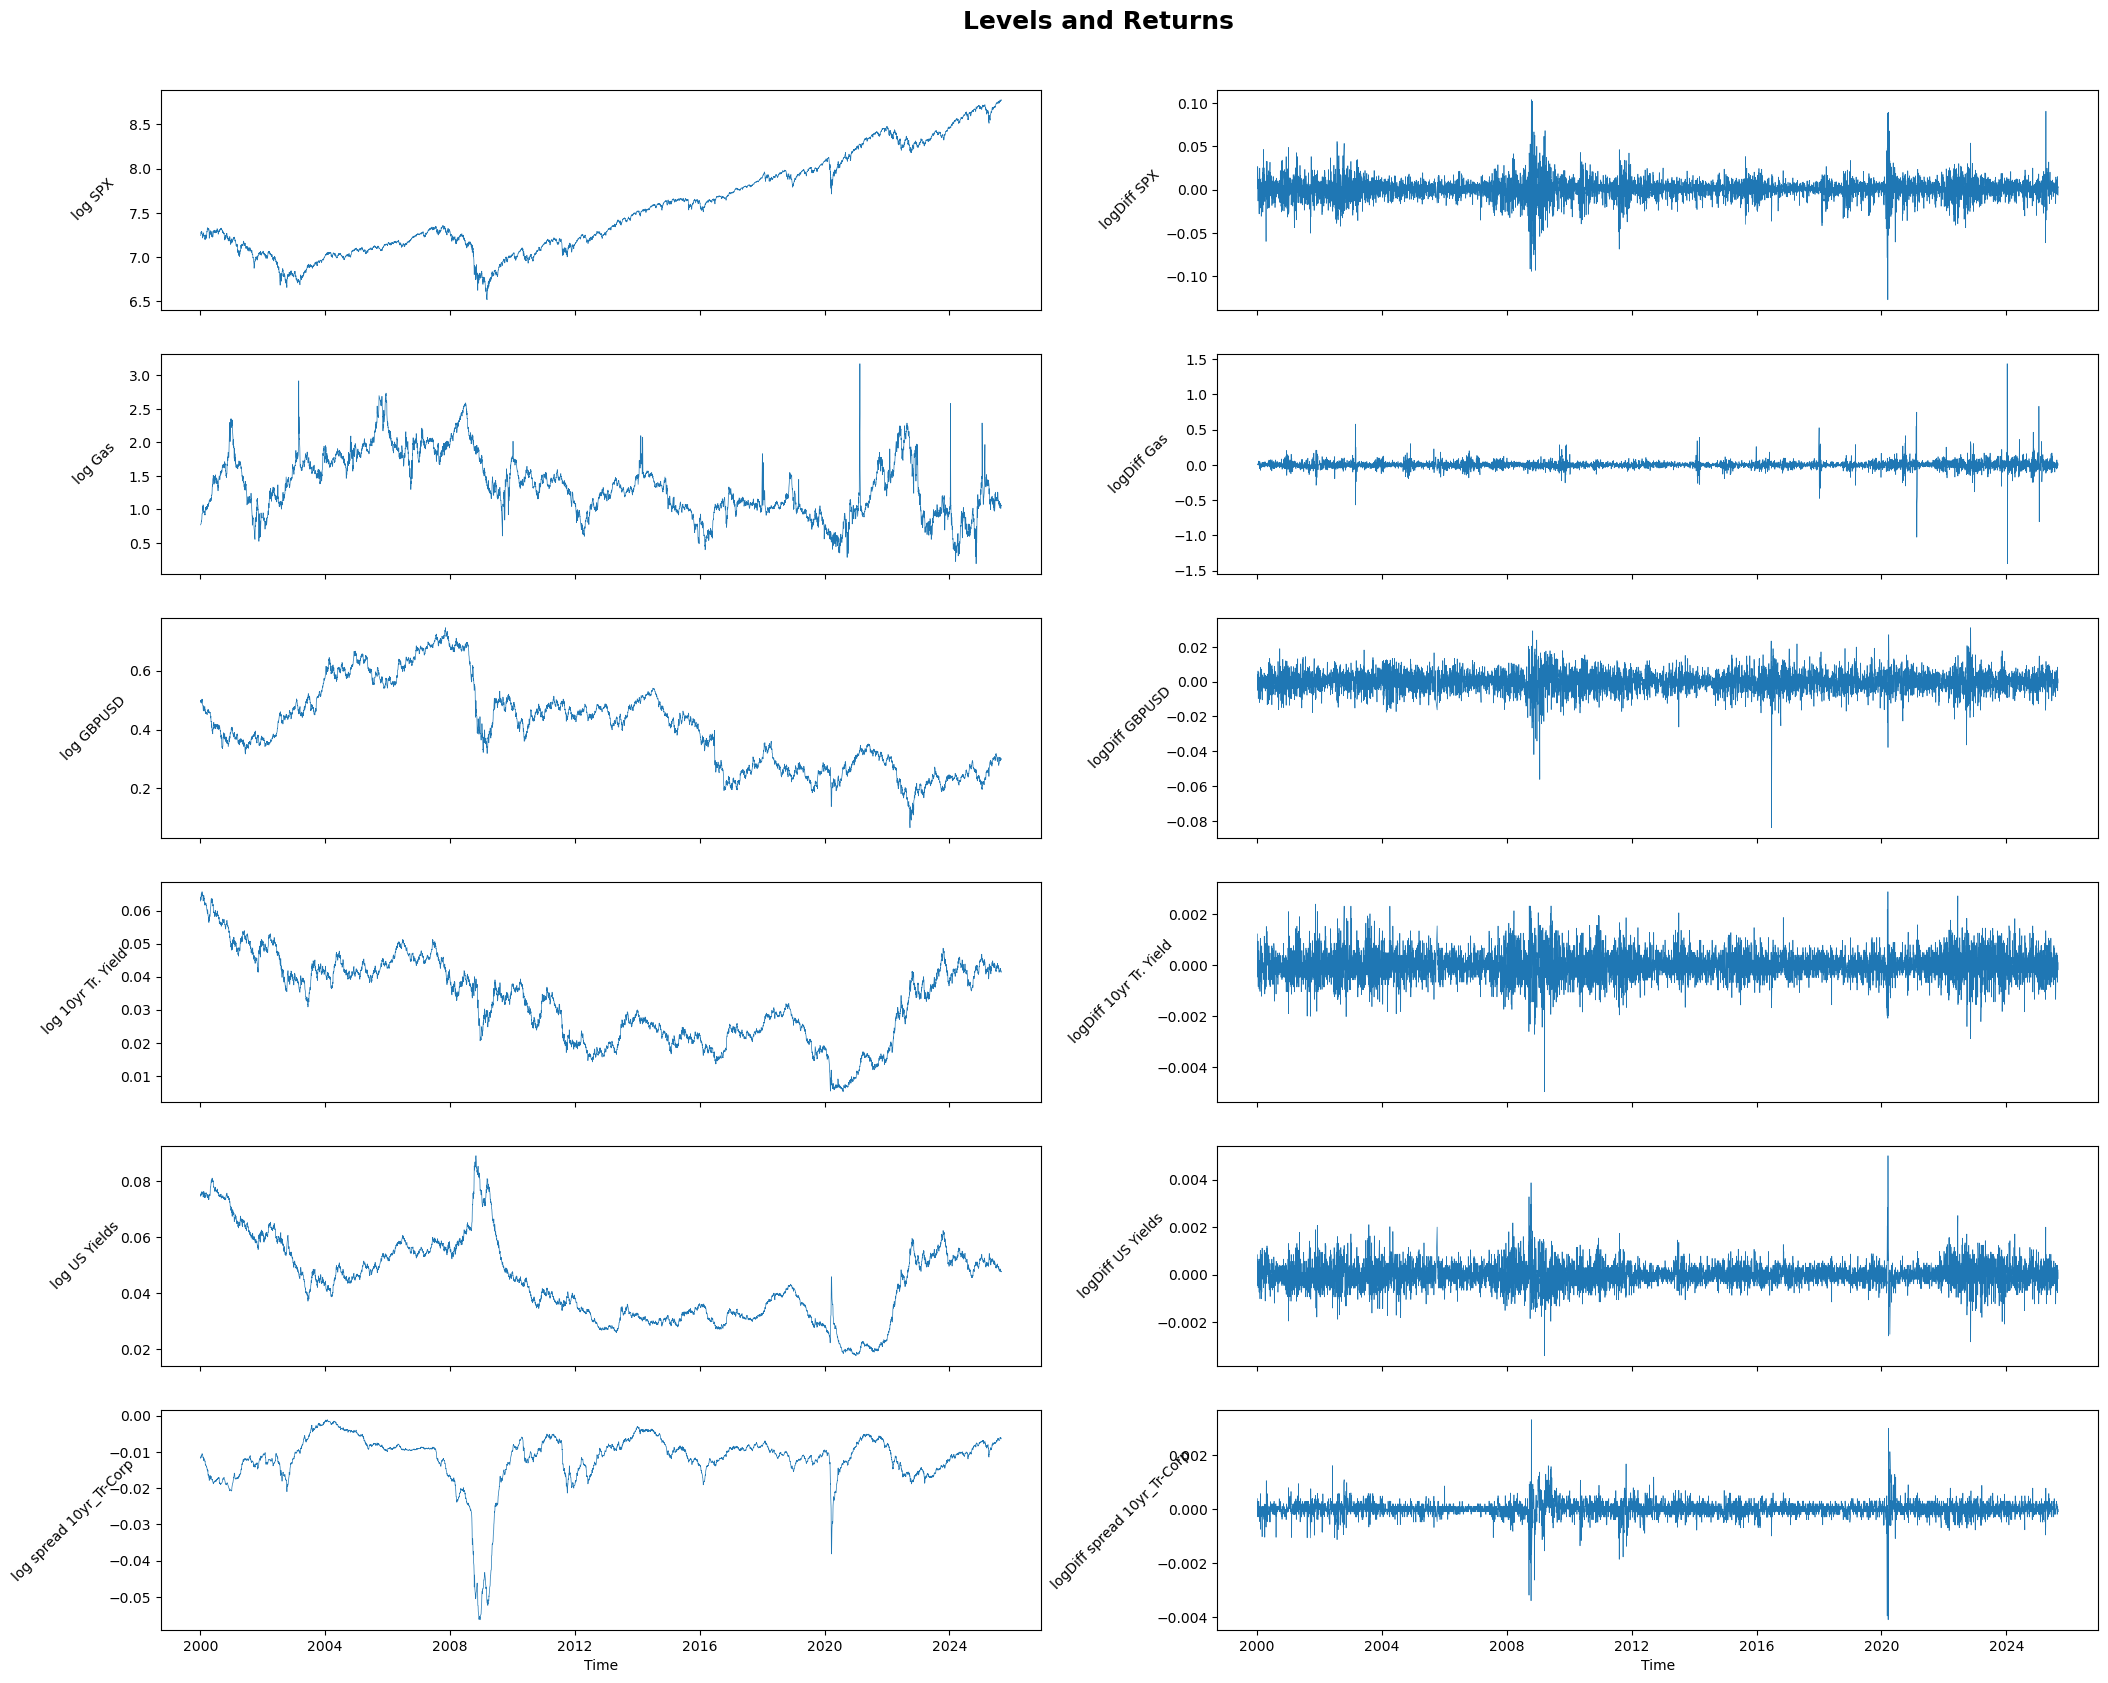

In [4]:
# Plot
names0 = df_log.columns.to_list()                                                       # Subplots names Col 0
names1 = df_log_diff.columns.to_list()                                                  # ' ' ' ' ' ' '  Col 1
nrows = 6                                               
ncols = 2
lw = .5
fig, axs = plt.subplots(nrows, ncols, sharex=True, figsize=(25, 20))                    # Plot Settings
plt.suptitle('Levels and Returns', y=0.92, fontsize=18, fontweight='bold')              # Plot Title
axs[-1, 0].set_xlabel('Time')                                                           # Plot common X-axis name
axs[-1, 1].set_xlabel('Time')                                                           # Plot common X-axis name

column = 0                                                                              # Index for plotting each column
for i in range(nrows):
    axs[i, 0].plot(df_log.index, df_log.iloc[:, column], linewidth=lw)                  # first-column subplot (Level)
    axs[i, 0].set_ylabel(f'{names0[column]}', rotation=45, labelpad=25, va='center')    # first subplot Y Label

    axs[i, 1].plot(df_log_diff.index, df_log_diff.iloc[:, column], linewidth=lw)        # second-column plot (Return)
    axs[i, 1].set_ylabel(f'{names1[column]}', rotation=45, labelpad=25, va='center')    # second subplot Y Label
    
    column += 1
plt.show()

In [5]:
# Table with the Descriptive Statistics
descriptive_stats = df_log_diff.describe().T
descriptive_stats['skew'] = df_log_diff.skew()
descriptive_stats['kurtosis'] = df_log_diff.kurt()
descriptive_stats = descriptive_stats.T
descriptive_stats

,logDiff SPX,logDiff Gas,logDiff GBPUSD,logDiff 10yr Tr. Yield,logDiff US Yields,logDiff spread 10yr_Tr-Corp
count,6372.000000,6372.000000,6372.000000,6372.000000,6372.000000,6.372000e+03
mean,0.000240,0.000045,-0.000030,-0.000003,-0.000004,8.404151e-07
std,0.012311,0.063056,0.005878,0.000566,0.000492,2.976069e-04
min,-0.127652,-1.401562,-0.083955,-0.004963,-0.003419,-4.083259e-03
25%,-0.004793,-0.022124,-0.003242,-0.000298,-0.000286,-9.972594e-05
50%,0.000639,0.000000,0.000066,0.000000,0.000000,0.000000e+00
75%,0.005973,0.020926,0.003353,0.000295,0.000284,1.009202e-04
max,0.104236,1.432814,0.031033,0.002875,0.005004,3.297235e-03
skew,-0.386924,0.103766,-0.839108,-0.012923,0.486818,-1.829081e+00
kurtosis,10.493532,112.698715,10.122400,2.375284,5.504676,3.302095e+01


In [6]:
# VarCov Matrix
varcov_matrix = df_log_diff.cov()
varcov_matrix

,logDiff SPX,logDiff Gas,logDiff GBPUSD,logDiff 10yr Tr. Yield,logDiff US Yields,logDiff spread 10yr_Tr-Corp
logDiff SPX,1.515556e-04,1.465128e-05,1.456535e-05,2.089690e-06,8.274796e-07,1.262210e-06
logDiff Gas,1.465128e-05,3.976017e-03,4.577137e-06,-2.489224e-07,-5.894773e-07,3.405550e-07
logDiff GBPUSD,1.456535e-05,4.577137e-06,3.454825e-05,-2.298237e-07,-4.454667e-07,2.156431e-07
logDiff 10yr Tr. Yield,2.089690e-06,-2.489224e-07,-2.298237e-07,3.203808e-07,2.368902e-07,8.349050e-08
logDiff US Yields,8.274796e-07,-5.894773e-07,-4.454667e-07,2.368902e-07,2.419696e-07,-5.079386e-09
logDiff spread 10yr_Tr-Corp,1.262210e-06,3.405550e-07,2.156431e-07,8.349050e-08,-5.079386e-09,8.856989e-08


In [7]:
# Correlation Matrix
corr_matrix = df_log_diff.corr()
corr_matrix

,logDiff SPX,logDiff Gas,logDiff GBPUSD,logDiff 10yr Tr. Yield,logDiff US Yields,logDiff spread 10yr_Tr-Corp
logDiff SPX,1.000000,0.018874,0.201290,0.299890,0.136644,0.344511
logDiff Gas,0.018874,1.000000,0.012350,-0.006974,-0.019005,0.018148
logDiff GBPUSD,0.201290,0.012350,1.000000,-0.069079,-0.154071,0.123276
logDiff 10yr Tr. Yield,0.299890,-0.006974,-0.069079,1.000000,0.850812,0.495634
logDiff US Yields,0.136644,-0.019005,-0.154071,0.850812,1.000000,-0.034697
logDiff spread 10yr_Tr-Corp,0.344511,0.018148,0.123276,0.495634,-0.034697,1.000000


In [8]:
from scipy.stats import norm

def pdf(df, name):
    #DataFrame to Series
    df = df.squeeze()
    
    # Moments of the Distribution
    mean = df.mean()
    st_dev = df.std()
    sk = df.skew()
    kurt = df.kurt()
    
    # Empirical Histogram
    plt.hist(df.to_numpy(), bins=100, density=True)

    # Theoretical PDF
    x = np.linspace(np.min(df), np.max(df), 100)
    pdf = norm.pdf(x, loc=mean, scale=st_dev)
    plt.plot(x, pdf)

    # Formatting a legend with main distribution specs
    text = (
        f"Mean = {mean:.2f}\n"
        f"Std.Dev. = {st_dev:.2f}\n"
        f"Skewness = {sk:.2f}\n"
        f"Kurtosis = {kurt:.2f}"
    )
    plt.legend(title=text, loc='upper right', fontsize=9, title_fontsize=10)
    
    # Labels and Title
    plt.xlabel(name)
    plt.ylabel('Density')
    plt.title(f'Empirical vs Normal PDF ({name})')
    
    plt.grid(alpha=0.3)
    plt.show()

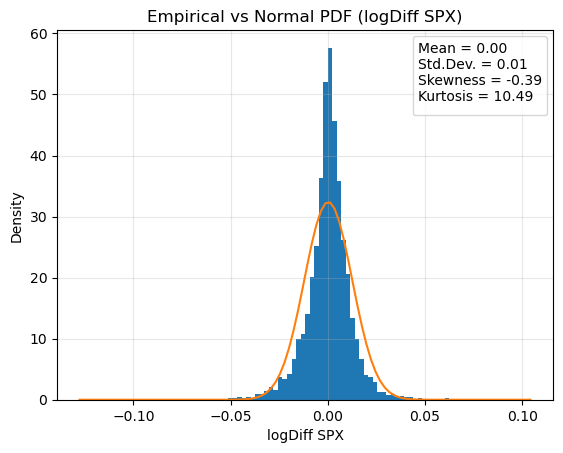

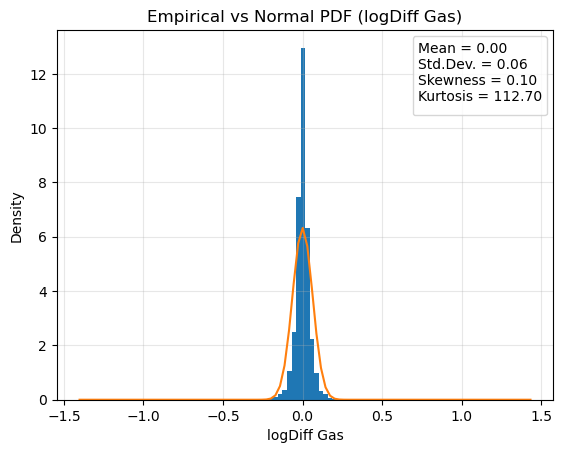

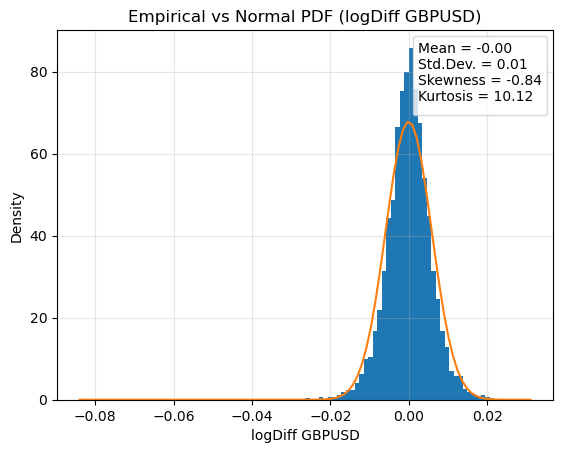

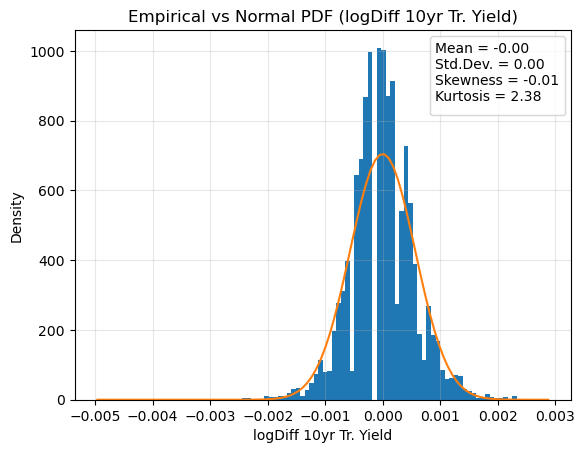

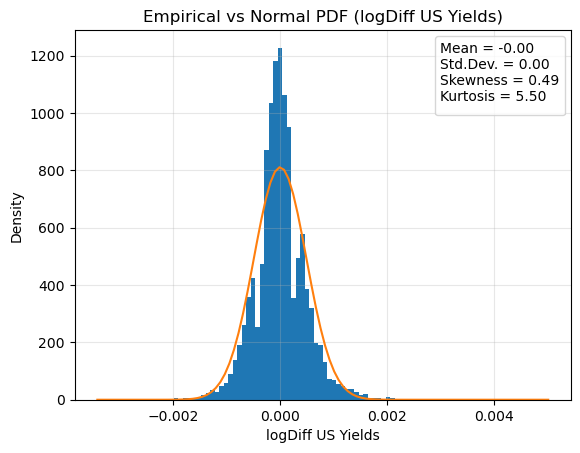

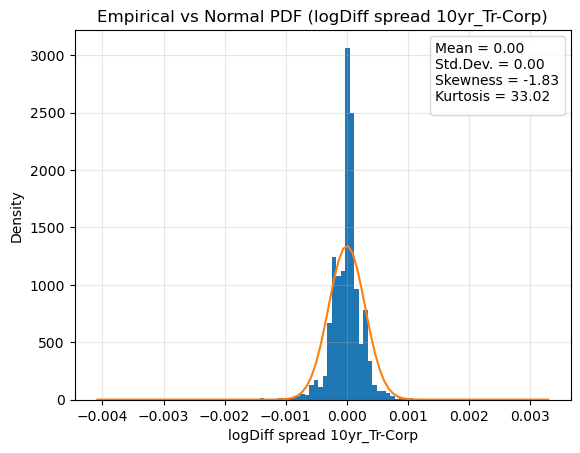

In [9]:
names = df_log_diff.columns.to_list()                                                  # ' ' ' ' ' ' '  Col 1
nrows = 6                                               

# Index for plotting each column

for i in range(nrows):
    pdf(df_log_diff.iloc[:, i], names[i])


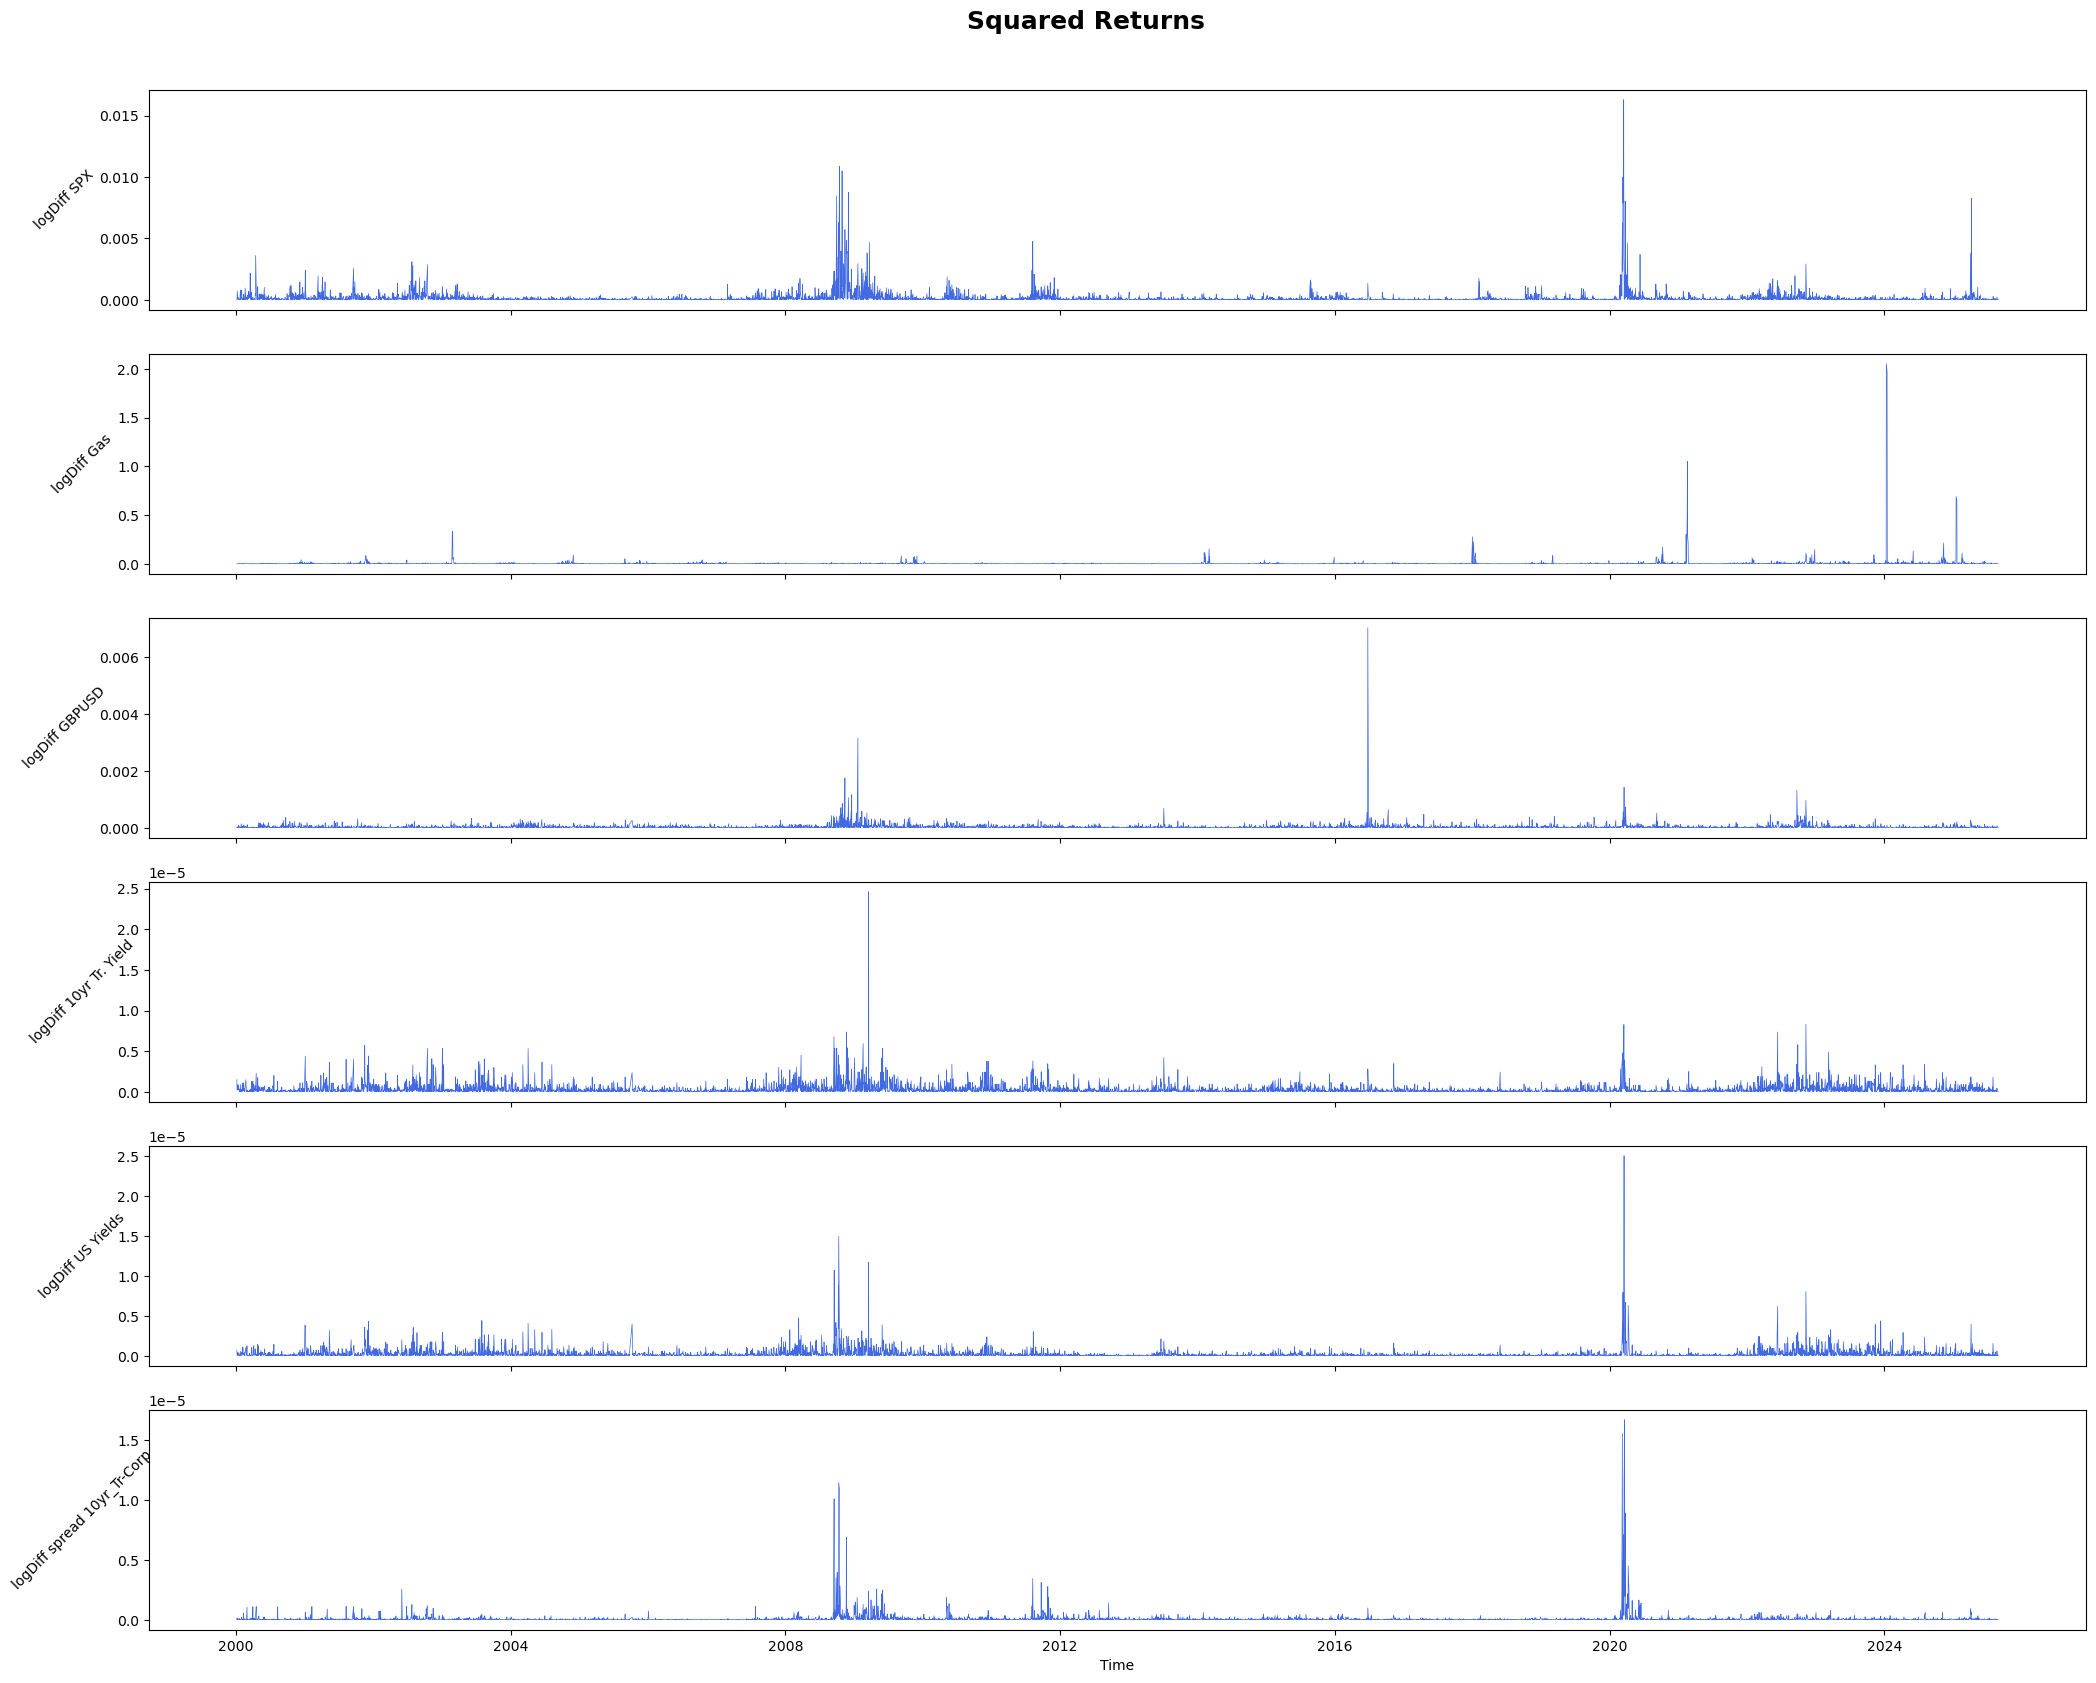

In [13]:
# Calculation of Squared Returns and Variance
df_sq_ret = df_log_diff ** 2                      
df_mean = df_log_diff.mean(axis=0)                
df_var = df_sq_ret - (df_mean ** 2)               

# Column Names
names_sq = df_sq_ret.columns.to_list()
names_var = df_var.columns.to_list()

# Plot Settings
nrows = 6
ncols = 1
lw = 0.5
fig, axs = plt.subplots(nrows, ncols, sharex=True, figsize=(25, 20))
plt.suptitle('Squared Returns', y=0.92, fontsize=18, fontweight='bold')

axs[-1].set_xlabel('Time')
# axs[-1, 1].set_xlabel('Time')

# Plot
column = 0
for i in range(nrows):
    # Left Column → squared returns
    axs[i].plot(df_sq_ret.index, df_sq_ret.iloc[:, column], linewidth=lw, color='royalblue')
    axs[i].set_ylabel(f'{names_sq[column]}', rotation=45, labelpad=25, va='center')

    # # Right Column → varianza centrata
    # axs[i, 1].plot(df_var.index, df_var.iloc[:, column], linewidth=lw, color='darkorange')
    # axs[i, 1].set_ylabel(f'{names_var[column]}', rotation=45, labelpad=25, va='center')

    column += 1

plt.show()

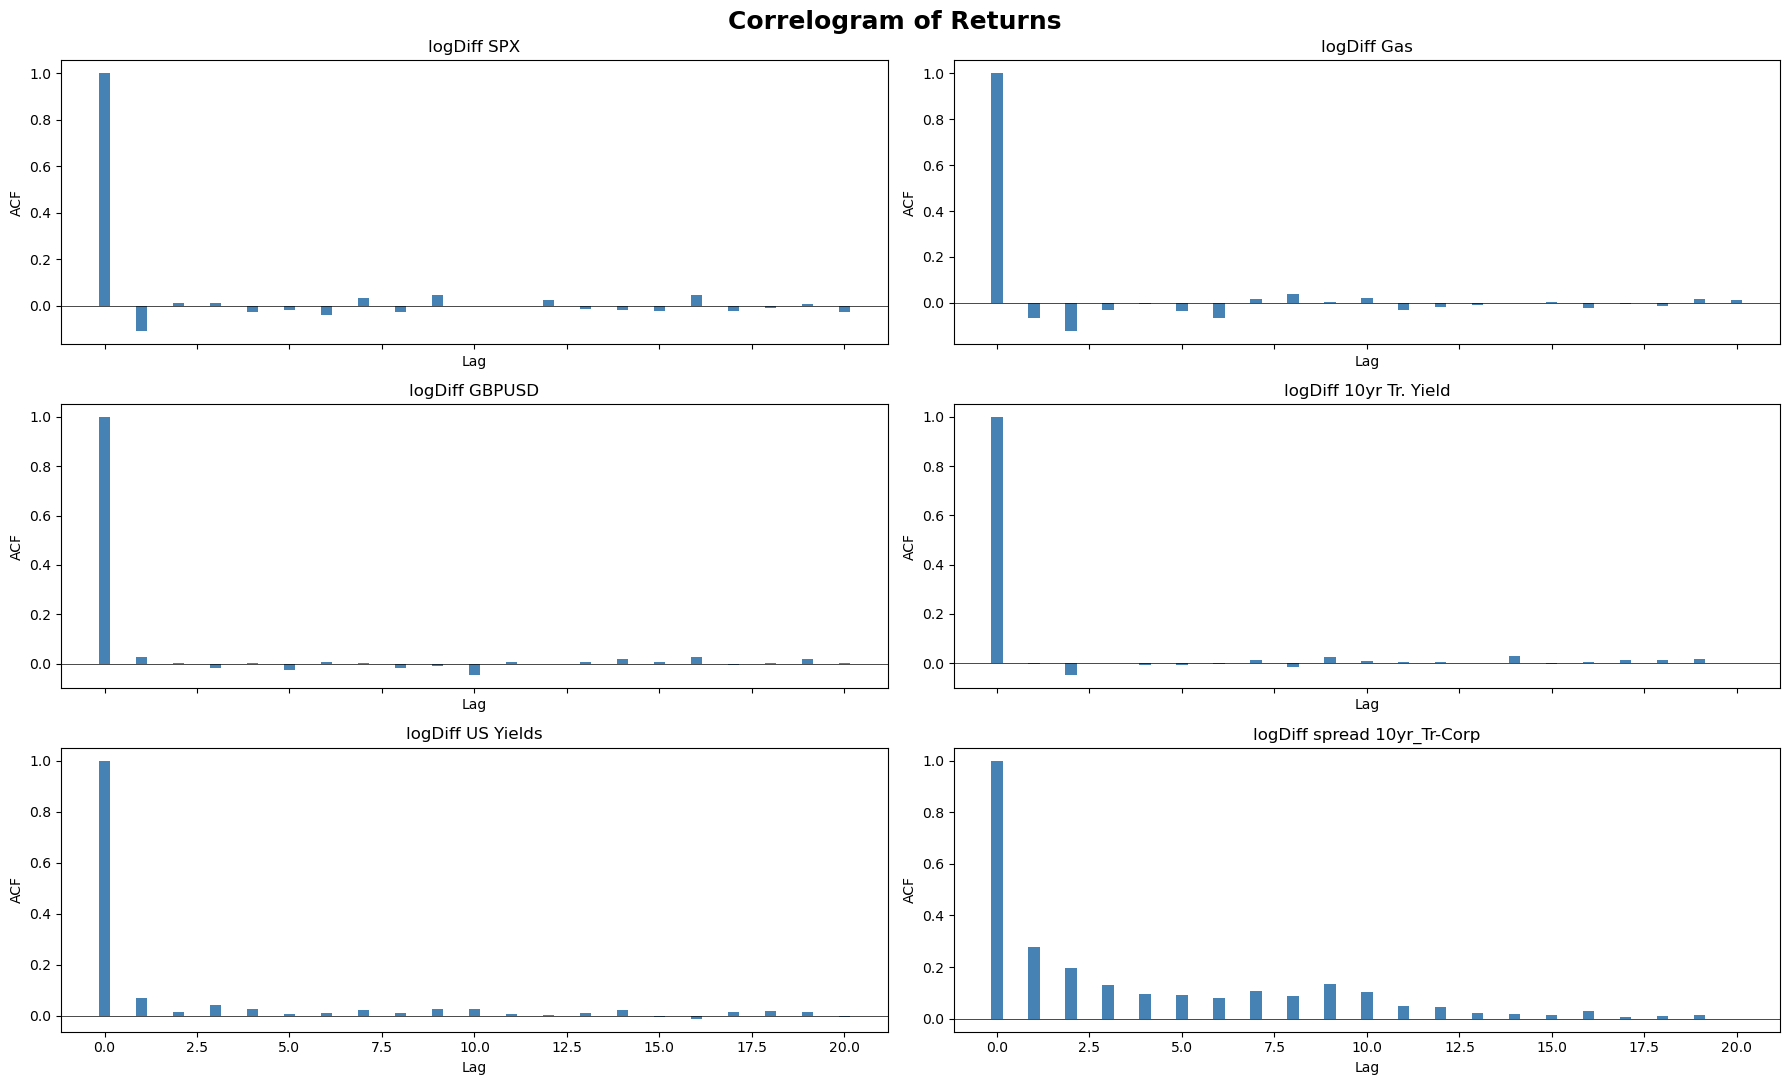

In [14]:
# Correlogram of Returns
max_lag = 20
names_ret = df_log_diff.columns.to_list()

nrows = 3
ncols = 2
fig, axs = plt.subplots(nrows, ncols, figsize=(18, 12), sharex=True)
plt.suptitle('Correlogram of Returns', y=0.93, fontsize=18, fontweight='bold')

def autocorr(x, max_lag):
    x = x - x.mean()
    denom = np.sum(x ** 2)
    acf_vals = [1.0]
    for k in range(1, max_lag + 1):
        num = np.sum(x[k:] * x[:-k])
        acf_vals.append(num / denom)
    return acf_vals

for idx, name in enumerate(names_ret):
    row, col = divmod(idx, ncols)
    series = df_log_diff[name].dropna().values
    acf_vals = autocorr(series, max_lag)
    lags = range(max_lag + 1)

    axs[row, col].bar(lags, acf_vals, width=0.3, color='steelblue')
    axs[row, col].axhline(0, color='black', linewidth=0.5)
    axs[row, col].set_title(name)
    axs[row, col].set_xlabel('Lag')
    axs[row, col].set_ylabel('ACF')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Question 2

In [15]:
# ADF Package
from statsmodels.tsa.stattools import adfuller

In [18]:
df_quarterly = df_log.resample('Q').mean()
df_quarterly_diff = df_quarterly.diff()

### Augmented Dickey-Fuller Test:
Now we are going to perfor the Unit Root Test for both the log-levels and, where applicable, the first difference of the time-series included in the perimeter.
Since we are using the package **adfuller** from **statsmodels**, the convention for the variables' names is different from Oxmetrics.
We will be considering the following equation:
$$\Delta{c_t}=\alpha+\beta t+\theta{c_{t-1}}+\delta_1{\Delta{c_{t-1}}}+u_t$$
$Hence, when reporting the results we will use the following convention:
$$
x_1\rightarrow\theta\\
\text{const}\rightarrow\alpha\\
x_2\rightarrow\delta_1\\
x_3\rightarrow\delta_2\\
x_{-1}\rightarrow\beta$$
Where, by $x_{-1}$ we refer to the last coefficient reported in the summary test. (applicable only if we will specify the use of a **trend variable**)


In [63]:
def augm_Dickey_Fueller(data: pd.Series, lags: int, regression: str):
    """
    Stima un ADF con lag e specificazione deterministica scelti a mano
    e stampa i risultati in uno stile simile a OxMetrics.
    
    data     : pandas.Series (livello, es. Dc)
    lags       : numero di lag in differenza (Dc_1, Dc_2, ...)
    regression : "n", "c", "ct" (nessuna, costante, costante+trend)
    """
    adf_results = adfuller(x=data, 
                        maxlag=lags, 
                        regression=regression, 
                        autolag=None, 
                        store=True,
                        regresults=True) # storing the results to facilitate the retrieving
    results_store = adf_results[-1]
    ols_res = results_store.resols

    params = ols_res.params
    t_values = ols_res.tvalues
    p_values = ols_res.pvalues
    names = ols_res.model.exog_names
    crit_value_1 = adf_results[2]['1%']
    crit_value_5 = adf_results[2]['5%']
    
    print(f"{'Variable':<12}{'Coefficient':>12}{'t-Value':>12}{'P-Value':>12}")
    for i in range(len(names)):
        print("-" * 48)
        print(f"{names[i]:<12}{params[i]:>12.5f}{t_values[i]:>12.5f}{p_values[i]:>12.4f}")
    print(f'Critical values used in ADF test: 5%={crit_value_5:.3f}, 1%={crit_value_1:.3f}')

In [64]:
adf_logSPX = augm_Dickey_Fueller(df_quarterly['log SPX'], 2, 'ct')

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.07302    -2.71869      0.0078
------------------------------------------------
x2               0.38635     3.90514      0.0002
------------------------------------------------
x3              -0.09722    -0.96494      0.3370
------------------------------------------------
const            0.47497     2.64830      0.0095
------------------------------------------------
x4               0.00170     3.37761      0.0011
Critical values used in ADF test: 5%=-3.455, 1%=-4.052
